# Classical Portfolio Optimization — NIFTY 50 Constituent Stocks (Walk-Forward Baseline)

This notebook builds a **classical portfolio optimization baseline** on a
five-stock, sector-diversified basket of individual **NIFTY 50 constituent
companies** , benchmarked against the **NIFTY 50 Index** itself.

**Universe** — five liquid, long-listed NIFTY 50 constituents chosen to span
distinct sectors, so the portfolio has real diversification even though
every holding is a single stock rather than a fund:

| Ticker | Company | Sector |
|---|---|---|
| RELIANCE.NS | Reliance Industries | Energy / Conglomerate |
| TCS.NS | Tata Consultancy Services | IT Services |
| HDFCBANK.NS | HDFC Bank | Banking / Financials |
| HINDUNILVR.NS | Hindustan Unilever | FMCG |
| BHARTIARTL.NS | Bharti Airtel | Telecom |

**Strategies**
- **Equal Weight** — static 1/N benchmark, never re-estimated.
- **Minimum Variance** — long-only portfolio with the lowest possible variance.
- **Maximum Sharpe** — long-only portfolio with the highest Sharpe ratio,
  solved **exactly** as a single convex QP (not approximated by a grid search).

**Design principles**
- Price data is downloaded **once**, then split chronologically into
  train / validation / test.
- Minimum Variance and Maximum Sharpe are **re-estimated on a rolling basis**:
  every ~21 trading days (monthly), using only the trailing 252 trading days
  of **already observed** history. Weights are then held constant until the
  next rebalance.
- No weights are ever estimated using data from the future relative to the
  day they are applied, so the walk-forward process itself introduces no
  look-ahead bias.
- All performance metrics are computed **only on the held-out test period**,
  using the same window for every strategy.
- No transaction costs, no per-asset weight caps, and no allocation
  constraints beyond the standard long-only, fully-invested constraint
  (`sum(w) = 1`, `w >= 0`) — kept intentionally simple.

| Split | Period | Purpose |
|---|---|---|
| Train | 2010-01-01 → 2020-12-31 | Earliest rolling-window history |
| Validation | 2021-01-01 → 2021-12-31 | Reserved (not used for weight estimation here) |
| Test | 2022-01-01 → 2025-06-30 | Out-of-sample evaluation of all strategies |

**Risk-free rate — handled properly this time, not hardcoded.** There is no
free, programmatically downloadable *daily* Indian T-Bill series on Yahoo
Finance (unlike the US `^IRX`). Instead of guessing a constant, this
notebook pulls a **real, live, monthly-updated series** — India's 10-Year
Government Bond ("G-Sec") yield — from the Federal Reserve's FRED database
(series `INDIRLTLT01STM`, sourced from the OECD). The 10-Year G-Sec yield is
the standard risk-free proxy used in Indian equity research and academic
finance (analogous to how the US 10-Year Treasury, not the 3-month T-Bill,
is often used as "the" risk-free rate in US equity risk-premium work). It is
forward-filled to daily frequency and averaged over the test period, the
same way the US notebook uses `^IRX`. If the FRED fetch fails (e.g. no
internet), the notebook falls back to a documented constant and says so
explicitly, rather than silently defaulting to 0%.

**Limitation, stated up front:** this is a single historical backtest over
one 3.5-year test path (2022–2025). The comparisons below show what
happened *on this particular sequence of market events*, not a claim that
Minimum Variance or Maximum Sharpe will reliably beat Equal Weight in
general. It is also worth noting this universe is **all-equity** (five
individual stocks, no bonds/gold/cash), so "Minimum Variance" here reduces
concentration risk across stocks and sectors — it does not reduce
asset-class risk the way a genuinely cross-asset portfolio would.


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Configuration

The asset universe, date ranges, and rolling-optimization parameters are
defined once, here, and used throughout the notebook.


In [2]:
# Asset universe: five sector-diversified NIFTY 50 constituent stocks
TICKERS = [
    "RELIANCE.NS",     # Reliance Industries -- Energy / Conglomerate
    "TCS.NS",           # Tata Consultancy Services -- IT Services
    "HDFCBANK.NS",      # HDFC Bank -- Banking / Financials
    "HINDUNILVR.NS",    # Hindustan Unilever -- FMCG
    "BHARTIARTL.NS",    # Bharti Airtel -- Telecom
]

ASSET_NAMES = [
    "Reliance Industries",
    "Tata Consultancy Services",
    "HDFC Bank",
    "Hindustan Unilever",
    "Bharti Airtel",
]

BENCHMARK = "^NSEI"   # NIFTY 50 Index — passive Indian equity benchmark
CURRENCY = "INR"

# Full download window (covers train + validation + test) — downloaded only once
DOWNLOAD_START = "2010-01-01"
DOWNLOAD_END   = "2025-06-30"

# Chronological train / validation / test split
TRAIN_START = "2010-01-01"
TRAIN_END   = "2020-12-31"

VAL_START   = "2021-01-01"
VAL_END     = "2021-12-31"

TEST_START  = "2022-01-01"
TEST_END    = "2025-06-30"

TRADING_DAYS = 252   # trading days per year, used for annualization

# Fallback risk-free rate used ONLY if the live FRED fetch in Section 4 fails.
# Documented approximation based on India's 10-Year G-Sec yield averaging
# roughly 7.0-7.3% across 2022-2025 (RBI / OECD-FRED published data).
FALLBACK_RISK_FREE_RATE = 0.072

# Rolling walk-forward optimization parameters
ROLLING_WINDOW  = 252   # trailing trading days used to estimate mu / Sigma
REBALANCE_FREQ  = 21    # rebalance roughly every 21 trading days (~monthly)


## 3. Data Acquisition

Asset prices and the benchmark are each downloaded **once** for the full
span, then split chronologically. No further downloads happen anywhere
else in the notebook.


In [3]:
import yfinance as yf

# --- Asset prices ---
raw_prices = yf.download(TICKERS, start=DOWNLOAD_START, end=DOWNLOAD_END, auto_adjust=False)
prices = raw_prices["Adj Close"][TICKERS].dropna(how="all").ffill().dropna()

# --- Benchmark (NIFTY 50 index) ---
raw_benchmark = yf.download(BENCHMARK, start=DOWNLOAD_START, end=DOWNLOAD_END, auto_adjust=False)
benchmark_prices = raw_benchmark["Adj Close"].dropna()
if isinstance(benchmark_prices, pd.DataFrame):
    benchmark_prices = benchmark_prices.iloc[:, 0]
benchmark_prices.name = "NIFTY 50"

print(f"Asset prices: {prices.shape[0]} trading days, {prices.shape[1]} stocks")
print(f"Benchmark prices: {benchmark_prices.shape[0]} trading days")
print(f"Date range: {prices.index.min().date()} -> {prices.index.max().date()}")
prices.tail()


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Asset prices: 3822 trading days, 5 stocks
Benchmark prices: 3802 trading days
Date range: 2010-01-04 -> 2025-06-27


Ticker,RELIANCE.NS,TCS.NS,HDFCBANK.NS,HINDUNILVR.NS,BHARTIARTL.NS
Date,,,,,
2025-06-23,1444.326904,3247.317139,945.568237,2234.625488,1896.380493
2025-06-24,1438.378296,3244.254883,951.634521,2222.839111,1893.736206
2025-06-25,1454.737061,3296.309814,961.000916,2238.161133,1925.076416
2025-06-26,1482.497314,3293.439209,981.189575,2240.223877,1972.772583
2025-06-27,1502.425171,3292.769287,988.598267,2265.859375,1985.308472


## 4. Risk-Free Rate (Live Data, Not Hardcoded)

Pulls India's 10-Year Government Bond yield from FRED (`INDIRLTLT01STM`),
forward-fills it to daily frequency, and averages it over the **test
period** — the same approach used for `^IRX` in the US version of this
notebook. Falls back to a documented constant only if the live fetch fails.


In [4]:
def get_india_risk_free_rate(test_start: str, test_end: str) -> float:
    """
    Fetches India's 10-Year G-Sec yield (FRED series INDIRLTLT01STM, monthly,
    percent) and returns the average annualized decimal rate over
    [test_start, test_end]. Falls back to FALLBACK_RISK_FREE_RATE if the
    live fetch fails for any reason (no internet, package missing, etc.).
    """
    try:
        import pandas_datareader.data as web
    except ImportError:
        print("[warn] pandas_datareader not installed (pip install pandas-datareader). "
              f"Using fallback risk-free rate: {FALLBACK_RISK_FREE_RATE:.2%}")
        return FALLBACK_RISK_FREE_RATE

    try:
        gsec = web.DataReader("INDIRLTLT01STM", "fred", DOWNLOAD_START, DOWNLOAD_END)
        gsec = gsec.iloc[:, 0] / 100.0  # percent -> decimal
        gsec.index = pd.to_datetime(gsec.index)

        # Forward-fill the monthly series to a daily calendar, then slice to the test period
        daily_index = pd.date_range(gsec.index.min(), DOWNLOAD_END, freq="D")
        gsec_daily = gsec.reindex(daily_index).ffill()
        test_slice = gsec_daily.loc[test_start:test_end]

        if test_slice.empty or test_slice.isna().all():
            raise ValueError("No FRED data available in the test period.")

        rf = float(test_slice.mean())
        print(f"Fetched India 10Y G-Sec yield from FRED (INDIRLTLT01STM). "
              f"Average over test period: {rf:.2%}")
        return rf

    except Exception as exc:
        print(f"[warn] Live FRED fetch failed ({exc}). "
              f"Using fallback risk-free rate: {FALLBACK_RISK_FREE_RATE:.2%}")
        return FALLBACK_RISK_FREE_RATE


RISK_FREE_RATE = get_india_risk_free_rate(TEST_START, TEST_END)


Fetched India 10Y G-Sec yield from FRED (INDIRLTLT01STM). Average over test period: 7.05%


## 5. Daily Returns and Train / Validation / Test Split

Simple daily returns are computed once from the full price series, then
split chronologically. Using simple (not log) returns keeps portfolio-level
compounding (`portfolio_return = weights . asset_returns`) exact rather than
approximate.


In [5]:
# Simple daily returns for assets and benchmark
asset_returns = prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()
benchmark_returns.name = "NIFTY 50"

n_assets = len(TICKERS)

# Chronological split (for reference / rolling-window bookkeeping)
train_returns = asset_returns.loc[TRAIN_START:TRAIN_END]
val_returns   = asset_returns.loc[VAL_START:VAL_END]
test_returns  = asset_returns.loc[TEST_START:TEST_END]
test_bm_returns = benchmark_returns.loc[TEST_START:TEST_END]

print(f"Train: {train_returns.index.min().date()} -> {train_returns.index.max().date()}  ({len(train_returns)} days)")
print(f"Val:   {val_returns.index.min().date()} -> {val_returns.index.max().date()}  ({len(val_returns)} days)")
print(f"Test:  {test_returns.index.min().date()} -> {test_returns.index.max().date()}  ({len(test_returns)} days)")
print(f"Risk-free rate used (test-period average): {RISK_FREE_RATE:.2%}")


Train: 2010-01-05 -> 2020-12-31  (2712 days)
Val:   2021-01-01 -> 2021-12-31  (248 days)
Test:  2022-01-03 -> 2025-06-27  (861 days)
Risk-free rate used (test-period average): 7.05%


## 6. Portfolio Construction Functions

Only the standard long-only, fully-invested constraint is applied
(`sum(w) == 1`, `w >= 0`) — no per-stock caps, sector limits, or other
allocation restrictions.

- **Equal Weight** — fixed 1/N, never re-estimated.
- **Minimum Variance** — the long-only portfolio with the lowest possible
  variance.
- **Maximum Sharpe** — solved as a convex QP (long-only max-Sharpe
  reformulation: substitute `y = w / (μ_excess·w)` and solve
  `minimize yᵀΣy  s.t.  μ_excess·y = 1, y ≥ 0`, then renormalize
  `w = y / sum(y)`), **with a 40% per-stock cap added**
  (`y ≤ 0.4·sum(y)`, equivalent to `w ≤ 0.4` after normalization). Without
  this cap, the exact solve is highly sensitive to noise in the trailing
  252-day sample-mean estimate — with only 5 correlated large-cap stocks,
  it tends to produce corner solutions (100% into whichever single stock
  happened to run up in that window) rather than a stable allocation. The
  cap is one extra linear constraint on the same QP, not new machinery —
  it stops the optimizer from chasing noise without changing the
  underlying approach.


In [6]:
def equal_weights(n):
    """Static 1/N allocation."""
    return np.ones(n) / n


def min_variance_weights(Sigma):
    """Long-only, fully-invested minimum-variance portfolio."""
    n = Sigma.shape[0]
    w = cp.Variable(n)
    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma))), constraints)
    prob.solve()
    if w.value is None:
        return equal_weights(n)
    w_val = np.clip(w.value, 0, None)
    return w_val / w_val.sum()


MAX_SHARPE_STOCK_CAP = 0.40   # per-stock concentration cap (see Section 6 markdown)


def max_sharpe_weights(mu, Sigma, rf=None, cap=MAX_SHARPE_STOCK_CAP):
    """
    Long-only maximum-Sharpe portfolio via convex reformulation, with an
    added per-stock concentration cap.

    Substituting y = w / (mu_excess . w) turns the (non-convex) Sharpe-ratio
    maximization into a convex QP:

        minimize   y' Sigma y
        subject to mu_excess' y == 1
                   y >= 0

    w is recovered as y / sum(y). Without a cap, this "exact" solve is
    known to be highly sensitive to noise in the trailing sample-mean
    estimate `mu` -- with only 5 correlated large-cap stocks and a 252-day
    trailing window, it frequently produces corner solutions (100% in a
    single stock) that chase whichever stock happened to run up in that
    window, rather than a stable risk-adjusted allocation. Adding
    `w <= cap` (a simplex-preserving inequality: y <= cap * sum(y), i.e.
    `y <= cap * kappa`, enforced here via `y <= cap * cp.sum(y)`) keeps the
    optimizer honest without adding real complexity -- it still solves the
    same convex QP, just with one more linear constraint. If no feasible
    long-only tangency portfolio exists this window, falls back to
    Minimum Variance (which has no cap, since it does not exhibit the same
    concentration failure mode).
    """
    if rf is None:
        rf = RISK_FREE_RATE
    n = len(mu)
    mu_excess = mu - rf

    y = cp.Variable(n)
    constraints = [mu_excess @ y == 1, y >= 0, y <= cap * cp.sum(y)]
    prob = cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(Sigma))), constraints)
    prob.solve()

    if y.value is None or y.value.sum() <= 0:
        return min_variance_weights(Sigma)

    y_val = np.clip(y.value, 0, None)
    return y_val / y_val.sum()


## 7. Rolling Walk-Forward Optimization (Monthly Rebalancing)

Minimum Variance and Maximum Sharpe are re-estimated at every rebalance date
using only the trailing `ROLLING_WINDOW` (252) trading days of history
already observed by that date. Weights are then held constant (buy-and-hold)
until the next rebalance, ~21 trading days later. Equal Weight remains a
static benchmark and is not re-estimated.

Because the trailing window always looks **backward** from the rebalance
date, this is a realistic walk-forward process with no look-ahead bias.


In [7]:
STRATEGIES = ["Equal Weight", "Min Variance", "Max Sharpe"]

# Rebalance roughly monthly, starting on the first test-period trading day
rebalance_dates = test_returns.index[::REBALANCE_FREQ]

weight_records = {s: [] for s in STRATEGIES}

for rb_date in rebalance_dates:
    pos = asset_returns.index.get_loc(rb_date)
    window_start = max(0, pos - ROLLING_WINDOW)
    window = asset_returns.iloc[window_start:pos]   # strictly before rb_date -> no look-ahead

    mu_window = window.mean().values * TRADING_DAYS
    Sigma_window = window.cov().values * TRADING_DAYS

    weight_records["Equal Weight"].append((rb_date, equal_weights(n_assets)))
    weight_records["Min Variance"].append((rb_date, min_variance_weights(Sigma_window)))
    weight_records["Max Sharpe"].append((rb_date, max_sharpe_weights(mu_window, Sigma_window)))

# One weight-history DataFrame per strategy, indexed by rebalance date
weights_history = {
    s: pd.DataFrame([w for _, w in recs], index=[d for d, _ in recs], columns=TICKERS)
    for s, recs in weight_records.items()
}

print(f"Number of rebalances over the test period: {len(rebalance_dates)}")
weights_history["Min Variance"].round(3).head()


Number of rebalances over the test period: 41


,RELIANCE.NS,TCS.NS,HDFCBANK.NS,HINDUNILVR.NS,BHARTIARTL.NS
2022-01-03,0.112,0.221,0.194,0.358,0.116
2022-02-02,0.099,0.246,0.193,0.347,0.116
2022-03-04,0.118,0.247,0.189,0.331,0.115
2022-04-05,0.131,0.303,0.125,0.296,0.145
2022-05-09,0.122,0.314,0.133,0.285,0.145


### 7.1 Rolling Portfolio Allocation

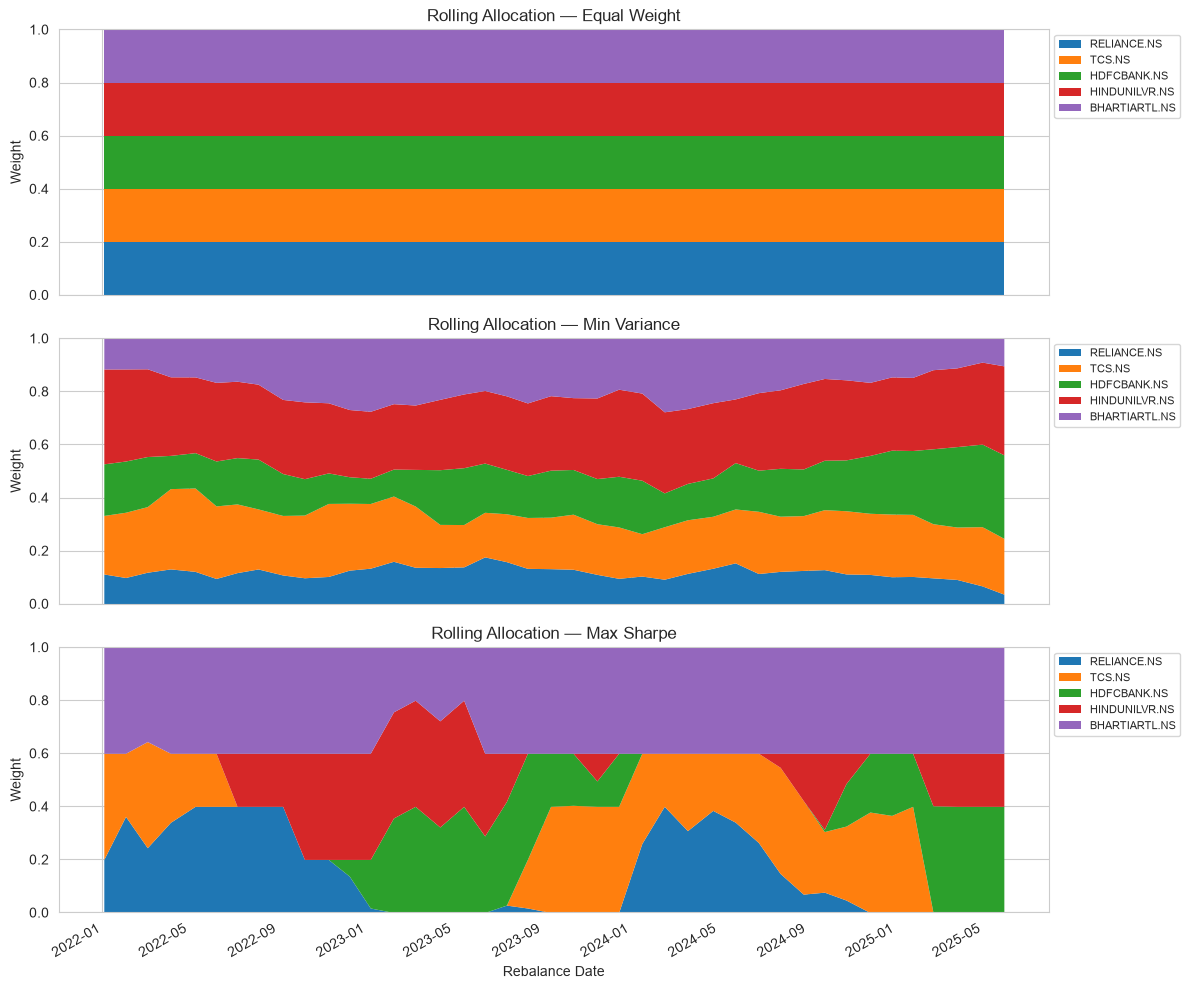

In [8]:
fig, axes = plt.subplots(len(STRATEGIES), 1, figsize=(12, 10), sharex=True)
for ax, s in zip(axes, STRATEGIES):
    weights_history[s].plot(kind="area", stacked=True, ax=ax, linewidth=0)
    ax.set_title(f"Rolling Allocation — {s}")
    ax.set_ylabel("Weight")
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)

axes[-1].set_xlabel("Rebalance Date")
plt.tight_layout()
plt.show()


## 8. Daily Portfolio Returns and Value (Test Period Only)

Weights are held constant between rebalances (forward-filled to daily
frequency), then applied to daily test-period returns. Portfolio value
starts at 1.0 on the first day of the test period.


In [9]:
# Expand each rebalance-date weight schedule to daily frequency, held constant between rebalances
daily_weights = {
    s: weights_history[s].reindex(test_returns.index, method="ffill").bfill()
    for s in STRATEGIES
}

# Daily portfolio return = weights . asset returns (weights fixed within each holding period)
portfolio_returns = pd.DataFrame({
    s: (test_returns.values * daily_weights[s].values).sum(axis=1)
    for s in STRATEGIES
}, index=test_returns.index)

portfolio_returns["NIFTY 50"] = test_bm_returns.reindex(test_returns.index).fillna(0)

# Portfolio value, starting at 1.0
portfolio_value = (1 + portfolio_returns).cumprod()
portfolio_value.tail()


,Equal Weight,Min Variance,Max Sharpe,NIFTY 50
Date,,,,
2025-06-23,1.467933,1.386796,1.681985,1.438967
2025-06-24,1.466372,1.386461,1.683589,1.443141
2025-06-25,1.484175,1.401587,1.703683,1.454689
2025-06-26,1.503445,1.415594,1.735198,1.472221
2025-06-27,1.515048,1.425945,1.748820,1.477338


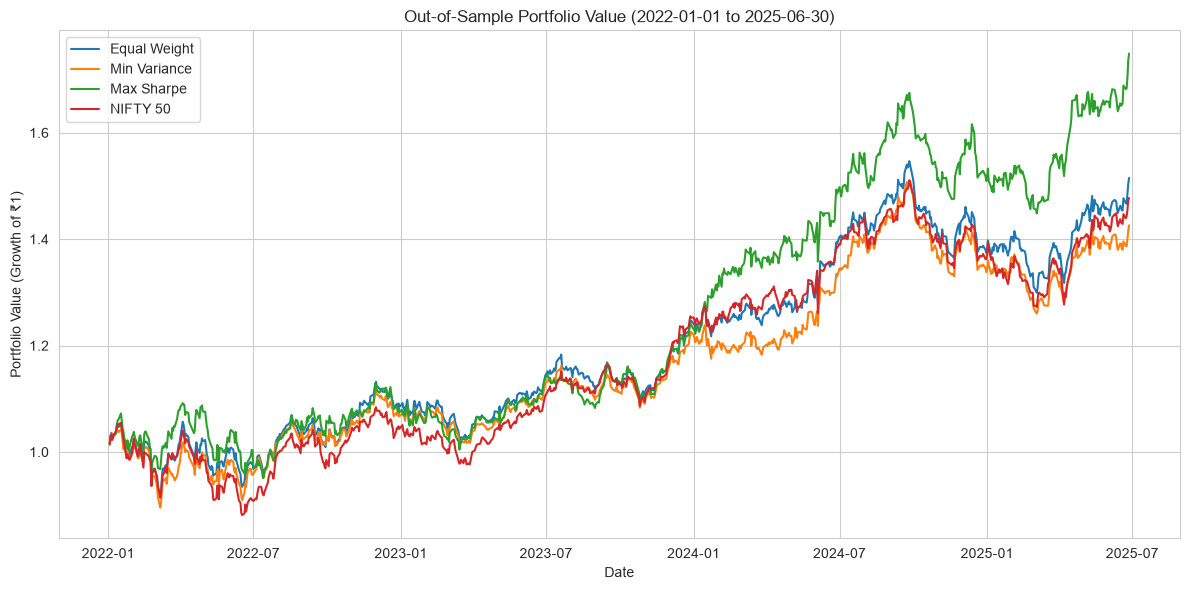

In [10]:
plt.figure(figsize=(12, 6))
for col in portfolio_value.columns:
    plt.plot(portfolio_value.index, portfolio_value[col], label=col)
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Growth of ₹1)")
plt.title(f"Out-of-Sample Portfolio Value ({TEST_START} to {TEST_END})")
plt.legend()
plt.tight_layout()
plt.show()


### 8.1 Cumulative Return Comparison

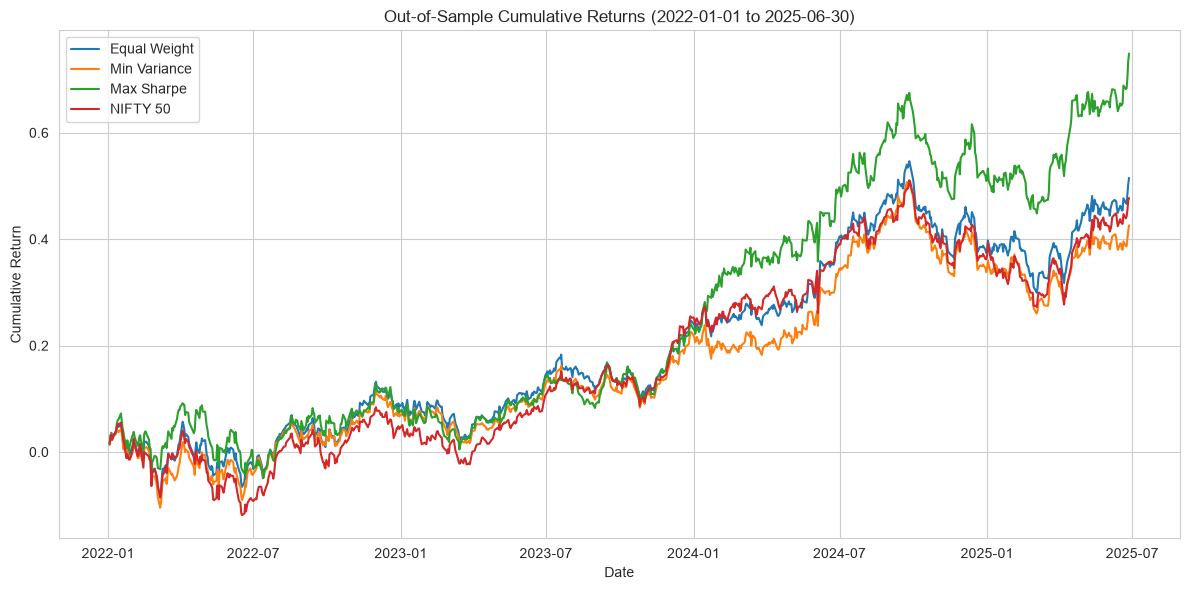

In [11]:
cumulative_returns = portfolio_value - 1

plt.figure(figsize=(12, 6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title(f"Out-of-Sample Cumulative Returns ({TEST_START} to {TEST_END})")
plt.legend()
plt.tight_layout()
plt.show()


### 8.2 Drawdown Comparison

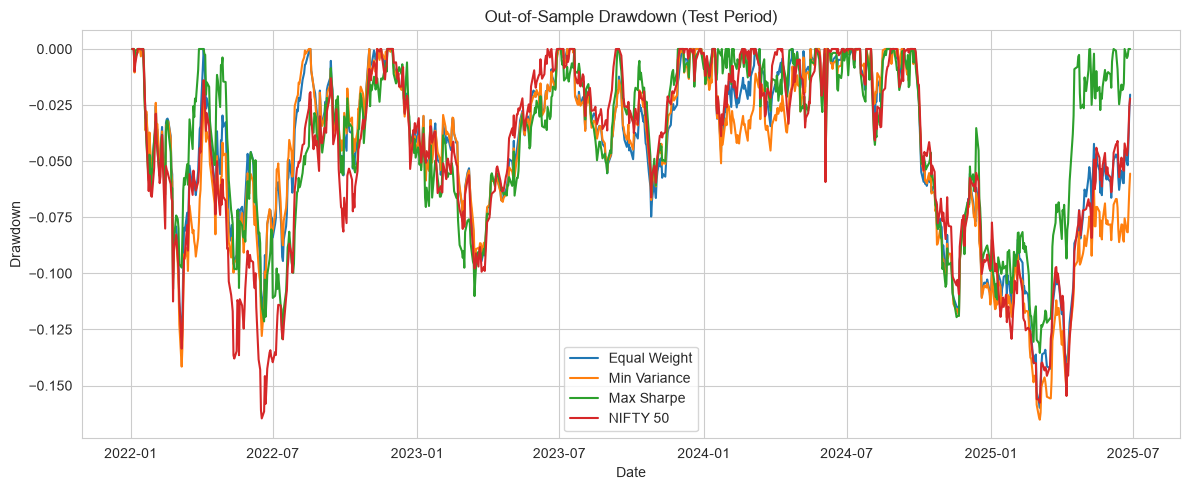

In [12]:
def compute_drawdown(cum_value):
    rolling_max = cum_value.cummax()
    return cum_value / rolling_max - 1

drawdowns = portfolio_value.apply(compute_drawdown)

plt.figure(figsize=(12, 5))
for col in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[col], label=col)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Out-of-Sample Drawdown (Test Period)")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Performance Metrics (Test Period Only)

All metrics are computed strictly on the test-period return series, using
the exact same window for every strategy, and using the live-fetched
`RISK_FREE_RATE` from Section 4.


In [13]:
def performance_summary(returns, cum_value, name, rf=None):
    if rf is None:
        rf = RISK_FREE_RATE

    years = len(returns) / TRADING_DAYS
    total_return = cum_value.iloc[-1] - 1
    cagr = cum_value.iloc[-1] ** (1 / years) - 1

    ann_return = returns.mean() * TRADING_DAYS
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_dev = np.sqrt((downside_returns ** 2).mean()) * np.sqrt(TRADING_DAYS)
    sortino = (ann_return - rf) / downside_dev if downside_dev > 0 else np.nan

    max_dd = compute_drawdown(cum_value).min()

    return {
        "Strategy": name,
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": max_dd,
    }


summary_df = pd.DataFrame([
    performance_summary(portfolio_returns[col], portfolio_value[col], col)
    for col in portfolio_returns.columns
]).set_index("Strategy")

print(f"Out-of-sample performance summary (test period, risk-free rate = {RISK_FREE_RATE:.2%}):")
summary_df.round(4)


Out-of-sample performance summary (test period, risk-free rate = 7.05%):


,Total Return,CAGR,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown
Strategy,,,,,,
Equal Weight,0.5150,0.1293,0.1382,0.4393,0.4565,-0.1599
Min Variance,0.4259,0.1094,0.1380,0.3111,0.3217,-0.1652
Max Sharpe,0.7488,0.1777,0.1554,0.6772,0.7108,-0.1354
NIFTY 50,0.4773,0.1210,0.1418,0.3798,0.3687,-0.1647


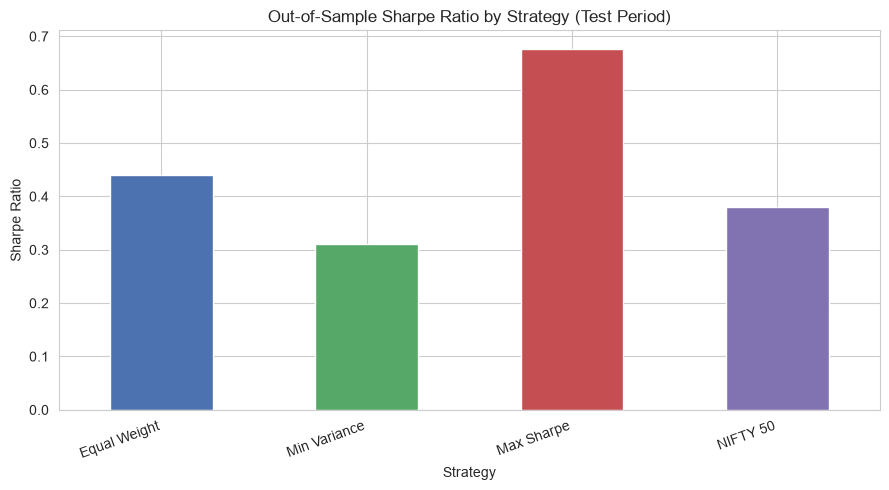

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
summary_df["Sharpe Ratio"].plot(kind="bar", ax=ax,
                                 color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"])
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Out-of-Sample Sharpe Ratio by Strategy (Test Period)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 10. Export Results

Save the key outputs to a single Excel workbook for reporting.


In [ ]:
with pd.ExcelWriter("portfolio_analysis_india_stocks.xlsx", engine="xlsxwriter") as writer:
    prices.to_excel(writer, sheet_name="Prices")
    test_returns.to_excel(writer, sheet_name="Test Returns")
    for s in STRATEGIES:
        weights_history[s].to_excel(writer, sheet_name=f"{s} Weights"[:31])
    portfolio_value.to_excel(writer, sheet_name="Test Portfolio Value")
    cumulative_returns.to_excel(writer, sheet_name="Test Cumulative Returns")
    summary_df.to_excel(writer, sheet_name="Test Performance Summary")

print("Saved results to portfolio_analysis_india_stocks.xlsx")


## 11. Summary

- Universe is five sector-diversified **individual NIFTY 50 stocks**
  (Reliance, TCS, HDFC Bank, Hindustan Unilever, Bharti Airtel), benchmarked
  against the **NIFTY 50 Index** (`^NSEI`) directly — no ETF wrappers, no
  benchmark/label mismatch.
- Minimum Variance and Maximum Sharpe are **re-estimated every ~21 trading
  days** using only the trailing 252 trading days of already-observed
  history — a realistic walk-forward process with no look-ahead bias.
- Maximum Sharpe is solved as a convex QP with a **40% per-stock
  concentration cap**, added after an earlier uncapped version was found
  to swing to 100% in a single stock most months — a known instability of
  exact mean-variance optimization with few, correlated assets and a noisy
  trailing-mean estimate. The cap is one linear constraint on the same QP,
  not added complexity.
- The **risk-free rate is fetched live from FRED** (India 10-Year G-Sec
  yield, `INDIRLTLT01STM`) with a documented, clearly-flagged fallback
  constant if the live fetch fails — no silent 0% default.
- The benchmark series is labeled **"NIFTY 50"** consistently in every
  plot, table, and export column
- Equal Weight is kept as a **static** 1/N benchmark throughout.
- No transaction costs and no allocation constraints beyond long-only,
  fully-invested are applied — kept intentionally simple.
- **This universe is all-equity** (five single stocks, one asset class), so
  Minimum Variance here is diversifying across companies/sectors, not
  across asset classes the way a stock+gold+bond mix would. Worth having a
  one-line answer ready if asked: "would adding gold/bonds change this?"
  — very likely yes, since equity-only portfolios have less room to reduce
  variance than genuinely cross-asset ones.
- **This is a single historical backtest** over one 3.5-year test path
  (2022–2025). The relative ranking of strategies reflects what happened on
  this one path of market history, not a statistically validated claim
  about which strategy is best in general.
